In [ ]:
# 📊 COMPREHENSIVE EDA GUIDE USING PYTHON
# A Complete Guide for Data Scientists & Analysts

# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for desi swag 😉
sns.set_style("darkgrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("📚 Libraries loaded successfully! Chalo, ab data ki duniya explore karte hain...")

📚 Libraries loaded successfully! Chalo, ab data ki duniya explore karte hain...


In [2]:
# Cell 2: Load Dataset (Titanic - The Classic!)
# We'll use the famous Titanic dataset - it's like the butter chicken of EDA datasets! 🍗

# Load data
df = sns.load_dataset('titanic')

# Basic overview
print("👋 First look at our data:")
display(df.head())

print(f"\n📐 Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n👨‍👩‍👧‍👦 Dataset contains {df.shape[0]} passengers ki kahani")

👋 First look at our data:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



📐 Shape: 891 rows, 15 columns

👨‍👩‍👧‍👦 Dataset contains 891 passengers ki kahani


In [3]:
# Cell 3: Understanding Data Composition - The Foundation! 📦

print("🔍 DATA COMPOSITION - Let's see what we're dealing with:\n")

# Pillar 1: Data Composition Analysis
print("1️⃣ Basic Info:")
df.info()

print("\n" + "="*60)
print("2️⃣ Column Names & Data Types:")
print(df.dtypes.to_string())

print("\n" + "="*60)
print("3️⃣ Missing Values - Kahan kahan gadbad hai:")
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
display(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "="*60)
print("4️⃣ Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

🔍 DATA COMPOSITION - Let's see what we're dealing with:

1️⃣ Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

2️⃣ C

,Missing Count,Missing %
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22



4️⃣ Unique Values per Column:
survived: 2 unique values
pclass: 3 unique values
sex: 2 unique values
age: 88 unique values
sibsp: 7 unique values
parch: 7 unique values
fare: 248 unique values
embarked: 3 unique values
class: 3 unique values
who: 3 unique values
adult_male: 2 unique values
deck: 7 unique values
embark_town: 3 unique values
alive: 2 unique values
alone: 2 unique values


In [4]:
# Cell 4: Data Cleaning - Making it 'suthra' (clean)! ✨

print("🧹 DATA CLEANING - Time to make our data spotless like Ammi's kitchen!")

# Create a copy to preserve original
df_cleaned = df.copy()

print("1️⃣ Handling Missing Values:")

# Age: Fill with median (more robust than mean)
print(f"   Age missing: {df_cleaned['age'].isnull().sum()}")
df_cleaned['age'].fillna(df_cleaned['age'].median(), inplace=True)
print(f"   Age filled with median: {df_cleaned['age'].median():.1f} years")

# Embarked: Fill with mode (most frequent)
print(f"   Embarked missing: {df_cleaned['embarked'].isnull().sum()}")
df_cleaned['embarked'].fillna(df_cleaned['embarked'].mode()[0], inplace=True)
print(f"   Embarked filled with mode: {df_cleaned['embarked'].mode()[0]}")

# Deck: Too many missing, let's see if we should keep it
deck_missing_pct = df_cleaned['deck'].isnull().sum() / len(df_cleaned) * 100
print(f"   Deck missing: {deck_missing_pct:.1f}% - {'Dropping!' if deck_missing_pct > 70 else 'Keeping!'}")

# Drop columns with too many missing values
df_cleaned.drop(columns=['deck'], inplace=True)

print("\n2️⃣ Data Type Corrections:")
df_cleaned['age'] = df_cleaned['age'].astype(int)

print("\n3️⃣ Final Check:")
print(df_cleaned.info())
print("\n✅ Data cleaned! It's so clean you could eat off it... but please don't! 😄")

🧹 DATA CLEANING - Time to make our data spotless like Ammi's kitchen!
1️⃣ Handling Missing Values:
   Age missing: 177
   Age filled with median: 28.0 years
   Embarked missing: 2
   Embarked filled with mode: S
   Deck missing: 77.2% - Dropping!

2️⃣ Data Type Corrections:

3️⃣ Final Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    int64   
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  


In [5]:
# Cell 5: Statistical Summary - Numbers tell stories! 📈

print("📊 PILLAR 1: DATA COMPOSITION - Statistical Summary\n")

print("1️⃣ Descriptive Statistics (Numerical):")
display(df_cleaned.describe())

print("\n2️⃣ Categorical Variables Summary:")
for col in df_cleaned.select_dtypes(include=['object', 'category']).columns:
    print(f"\n{col.upper()}:")
    print(df_cleaned[col].value_counts())
    print(f"Categories: {df_cleaned[col].nunique()}")

print("\n3️⃣ Survival Rate (Our Target Variable):")
survival_rate = df_cleaned['survived'].mean() * 100
print(f"   Overall survival rate: {survival_rate:.1f}%")
print("   That's lower than my batting average in gully cricket! 🏏")

📊 PILLAR 1: DATA COMPOSITION - Statistical Summary

1️⃣ Descriptive Statistics (Numerical):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.345679,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.028212,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



2️⃣ Categorical Variables Summary:

SEX:
sex
male      577
female    314
Name: count, dtype: int64
Categories: 2

EMBARKED:
embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Categories: 3

CLASS:
class
Third     491
First     216
Second    184
Name: count, dtype: int64
Categories: 3

WHO:
who
man      537
woman    271
child     83
Name: count, dtype: int64
Categories: 3

EMBARK_TOWN:
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
Categories: 3

ALIVE:
alive
no     549
yes    342
Name: count, dtype: int64
Categories: 2

3️⃣ Survival Rate (Our Target Variable):
   Overall survival rate: 38.4%
   That's lower than my batting average in gully cricket! 🏏


📈 PILLAR 2: DATA DISTRIBUTION - Where the magic happens!



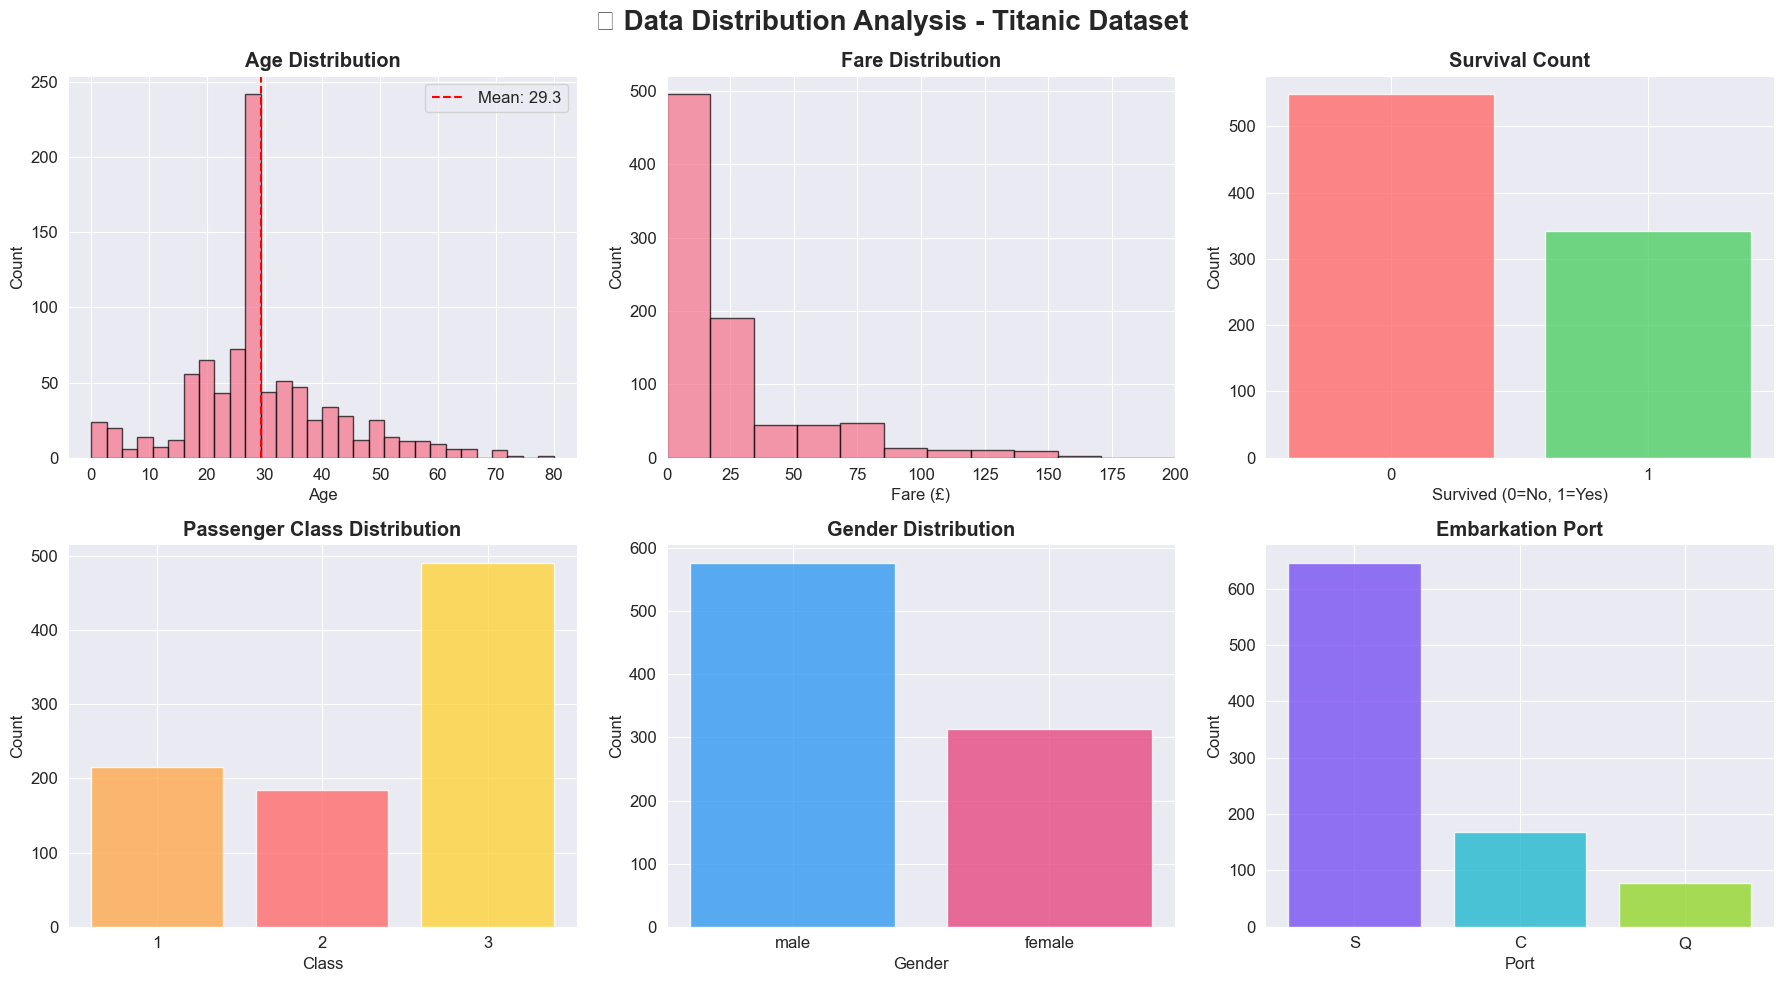


💡 INSIGHT: We can see most passengers were in their 20s-30s, with majority in 3rd class. 
   The fare distribution is heavily skewed - some people paid a lot more!


In [6]:
# Cell 6: PILLAR 2 - Data Distribution Analysis 📊

print("📈 PILLAR 2: DATA DISTRIBUTION - Where the magic happens!\n")

# Set up subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Data Distribution Analysis - Titanic Dataset', fontsize=20, fontweight='bold')

# 1. Age Distribution
axes[0,0].hist(df_cleaned['age'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Age Distribution', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df_cleaned['age'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned["age"].mean():.1f}')
axes[0,0].legend()

# 2. Fare Distribution
axes[0,1].hist(df_cleaned['fare'], bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Fare Distribution', fontweight='bold')
axes[0,1].set_xlabel('Fare (£)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xlim(0, 200)  # Limit outliers for visibility

# 3. Survived Distribution
survival_counts = df_cleaned['survived'].value_counts()
axes[0,2].bar(survival_counts.index, survival_counts.values, color=['#ff6b6b', '#51cf66'], alpha=0.8)
axes[0,2].set_title('Survival Count', fontweight='bold')
axes[0,2].set_xlabel('Survived (0=No, 1=Yes)')
axes[0,2].set_ylabel('Count')
axes[0,2].set_xticks([0, 1])

# 4. Class Distribution
class_counts = df_cleaned['pclass'].value_counts()
axes[1,0].bar(class_counts.index, class_counts.values, color=['#ffd43b', '#ffa94d', '#ff6b6b'], alpha=0.8)
axes[1,0].set_title('Passenger Class Distribution', fontweight='bold')
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks([1, 2, 3])

# 5. Gender Distribution
gender_counts = df_cleaned['sex'].value_counts()
axes[1,1].bar(gender_counts.index, gender_counts.values, color=['#339af0', '#e64980'], alpha=0.8)
axes[1,1].set_title('Gender Distribution', fontweight='bold')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Count')

# 6. Embarked Distribution
embarked_counts = df_cleaned['embarked'].value_counts()
axes[1,2].bar(embarked_counts.index, embarked_counts.values, color=['#7950f2', '#22b8cf', '#94d82d'], alpha=0.8)
axes[1,2].set_title('Embarkation Port', fontweight='bold')
axes[1,2].set_xlabel('Port')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: We can see most passengers were in their 20s-30s, with majority in 3rd class. \n   The fare distribution is heavily skewed - some people paid a lot more!")

📦 BOX PLOTS - Finding outliers like a detective! 🔍



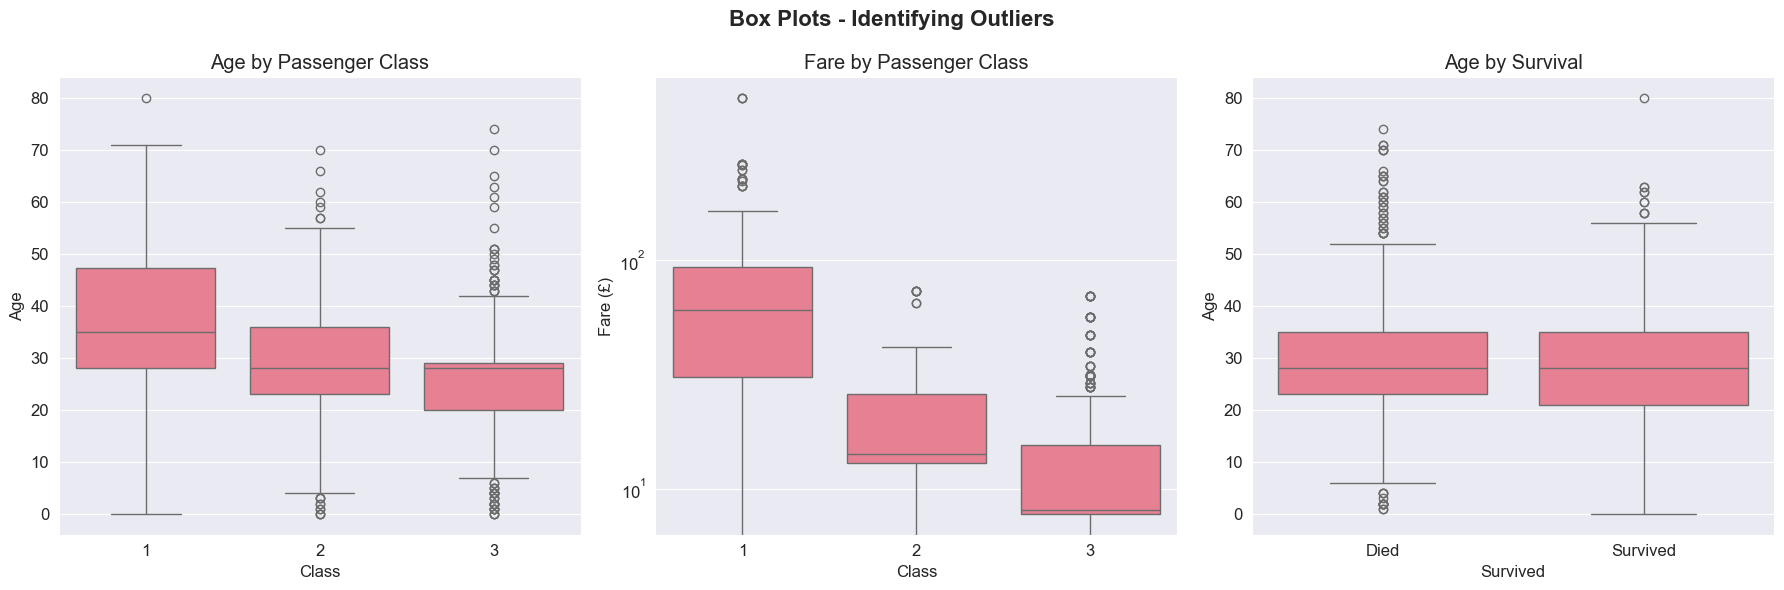

💡 INSIGHT: 1st class passengers paid WAY more (log scale shows massive difference).
   Age distribution is similar across classes, but survival might have age patterns!


In [7]:
# Cell 7: Advanced Distribution Plots - Box Plots for Outliers 📦

print("📦 BOX PLOTS - Finding outliers like a detective! 🔍\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots - Identifying Outliers', fontsize=16, fontweight='bold')

# Age by Class
sns.boxplot(data=df_cleaned, x='pclass', y='age', ax=axes[0])
axes[0].set_title('Age by Passenger Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Age')

# Fare by Class
sns.boxplot(data=df_cleaned, x='pclass', y='fare', ax=axes[1])
axes[1].set_title('Fare by Passenger Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Fare (£)')
axes[1].set_yscale('log')  # Log scale because of extreme outliers

# Age by Survival
sns.boxplot(data=df_cleaned, x='survived', y='age', ax=axes[2])
axes[2].set_title('Age by Survival')
axes[2].set_xlabel('Survived')
axes[2].set_xticklabels(['Died', 'Survived'])
axes[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

print("💡 INSIGHT: 1st class passengers paid WAY more (log scale shows massive difference).\n   Age distribution is similar across classes, but survival might have age patterns!")

🔗 PILLAR 3: DATA RELATIONSHIPS - How variables connect!


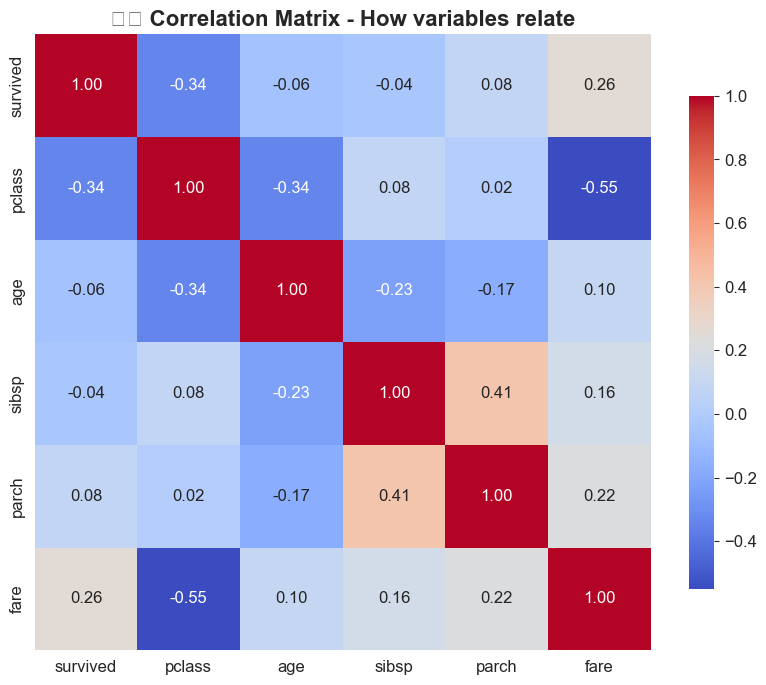


💡 INSIGHT: Survived has negative correlation with 'pclass' (higher class = better survival)
   and positive correlation with 'fare' (more money = better survival). Classic! 💸

📋 CROSS-TABS: Survival by Gender and Class

Survival Rate by Gender:


survived,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815



Survival Rate by Class:


survived,0,1
pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [8]:
# Cell 8: PILLAR 3 - Data Relationships 🔗

print("🔗 PILLAR 3: DATA RELATIONSHIPS - How variables connect!")

# Correlation Matrix for numerical variables
plt.figure(figsize=(10, 8))
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns
correlation_matrix = df_cleaned[numerical_cols].corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={'shrink': 0.8})
plt.title('🌡️ Correlation Matrix - How variables relate', fontsize=16, fontweight='bold')
plt.show()

print("\n💡 INSIGHT: Survived has negative correlation with 'pclass' (higher class = better survival)\n   and positive correlation with 'fare' (more money = better survival). Classic! 💸")

# Cross-tabulations (Categorical Relationships)
print("\n" + "="*60)
print("📋 CROSS-TABS: Survival by Gender and Class\n")

# Gender vs Survival
gender_survival = pd.crosstab(df_cleaned['sex'], df_cleaned['survived'], normalize='index') * 100
print("Survival Rate by Gender:")
display(gender_survival)

# Class vs Survival
class_survival = pd.crosstab(df_cleaned['pclass'], df_cleaned['survived'], normalize='index') * 100
print("\nSurvival Rate by Class:")
display(class_survival)

In [9]:
# Cell 4 (or copy this cleaning code):
df_cleaned = df.copy()

# Quick cleaning
df_cleaned['age'].fillna(df_cleaned['age'].median(), inplace=True)
df_cleaned['embarked'].fillna(df_cleaned['embarked'].mode()[0], inplace=True)
df_cleaned['age'] = df_cleaned['age'].astype(int)
df_cleaned.drop(columns=['deck'], inplace=True)
df_cleaned['count'] = 1  # Add this here for sunburst

print("✅ df_cleaned is now ready! Cell 9 chalao!")

✅ df_cleaned is now ready! Cell 9 chalao!
